In [200]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
import torchmetrics as tm

In [201]:
device = "cuda"
root_path = "/home/stefan/ioai-prep/kits/gaia/sudoku"

# MNIST training

## Data

In [202]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1 - x),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 1 - x),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train = datasets.MNIST(
    f"{root_path}/train/mnist", train=True, download=False, transform=train_transform
)
mnist_test = datasets.MNIST(
    f"{root_path}/train/mnist", train=False, download=False, transform=transform
)

print(f"MNIST train: {len(mnist_train)} images")
print(f"MNIST test:  {len(mnist_test)} images")

MNIST train: 60000 images
MNIST test:  10000 images


In [203]:
train_loader = DataLoader(
    mnist_train, batch_size=256, shuffle=True
)  # ConcatDataset([mnist_train, mnist_test])
test_loader = DataLoader(mnist_test, batch_size=256, shuffle=False)

batch = next(iter(train_loader))
[b.shape for b in batch]

[torch.Size([256, 1, 28, 28]), torch.Size([256])]

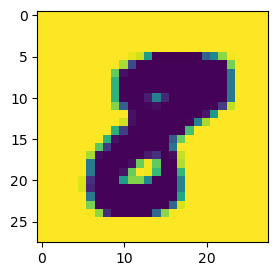

In [204]:
plt.figure(figsize=(3, 3))
plt.imshow(batch[0][0].permute(1, 2, 0))

## Model

In [205]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [206]:
model = LeNet().to(device)

model(batch[0].to(device)).shape

torch.Size([256, 10])

## Training

In [207]:
not_loaded = True

if not not_loaded:
    model.load_state_dict(torch.load(f"{root_path}/best.pt"))

In [208]:
epochs = 20 if not_loaded else 0
lr = 3e-3
best_so_far = 0

optimizer = torch.optim.AdamW(model.parameters(), lr, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=2e-4)

criterion = nn.CrossEntropyLoss()
acc = tm.Accuracy(task="multiclass", num_classes=10).to(device)

In [209]:
for epoch in range(1, epochs + 1):
    model.train()
    t_loss = 0.0
    for img, label in tqdm(train_loader):
        img, label = img.to(device), label.to(device)

        logits = model(img)
        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        t_loss += loss.item()
    scheduler.step()

    model.eval()
    v_loss = 0.0
    acc.reset()
    for img, label in tqdm(test_loader):
        img, label = img.to(device), label.to(device)

        with torch.no_grad():
            logits = model(img)
            loss = criterion(logits, label)
            acc(logits, label)

        v_loss += loss.item()

    t_loss = t_loss / len(train_loader)
    v_loss = v_loss / len(test_loader)
    if acc.compute() * 100 > best_so_far:
        best_so_far = acc.compute() * 100
        print("new best!")
        torch.save(model.state_dict(), f"{root_path}/best.pt")
    print(
        f"epoch {epoch}: t_loss={t_loss:.2f}, v_loss={v_loss:.2f}, acc={acc.compute()*100:.2f}"
    )

100%|██████████| 40/40 [00:01<00:00, 26.19it/s]


new best!
epoch 1: t_loss=0.27, v_loss=0.05, acc=98.26


100%|██████████| 40/40 [00:01<00:00, 25.88it/s]


new best!
epoch 2: t_loss=0.09, v_loss=0.04, acc=98.76


100%|██████████| 40/40 [00:01<00:00, 26.54it/s]


...

epoch 18: t_loss=0.01, v_loss=0.03, acc=99.30


100%|██████████| 40/40 [00:01<00:00, 26.56it/s]


epoch 19: t_loss=0.01, v_loss=0.03, acc=99.33


100%|██████████| 40/40 [00:01<00:00, 28.61it/s]

epoch 20: t_loss=0.01, v_loss=0.03, acc=99.31


In [210]:
model.load_state_dict(torch.load(f"{root_path}/best.pt"))

<All keys matched successfully>

# Test inference

In [211]:
test_boards = []
for i in range(200):
    img = Image.open(f"{root_path}/test/test_boards/{i}.png").convert("L")
    test_boards.append(np.array(img))

print(f"loaded {len(test_boards)} test boards, shape: {test_boards[0].shape}")

loaded 200 test boards, shape: (252, 252)


Each board is a 252×252 pixel grayscale PNG image containing 81 cells in a 9×9 grid. Each cell is exactly 28×28 pixels.

In [246]:
test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
])

def get_grid(idx):
    grid = np.zeros((9, 9), dtype=np.int32)

    for i in range(0, 9):
        for j in range(0, 9):
            img = test_boards[idx][28 * i : 28 * (i + 1), 28 * j : 28 * (j + 1)]  
            t = [test_transform]

            ch = np.zeros((10,))
            for trans in t:
                im = trans(img).permute(0, 1, 2).unsqueeze(0).to(device)
                number = (
                    F.softmax(model(im), dim=-1).argmax(dim=-1).detach().cpu().item()
                )
                ch[number] += 1
            grid[i, j] = np.int32(ch.argmax())
    return grid

In [247]:
def valid_sudoku(grid):
    def is_valid_set(nums):
        return len(nums) == len(set(nums))

    # Check rows and columns
    for i in range(9):
        if not is_valid_set(grid[i, :]) or not is_valid_set(grid[:, i]):
            return False

    # Check 3x3 blocks
    for r in range(0, 9, 3):
        for c in range(0, 9, 3):
            block = grid[r : r + 3, c : c + 3].flatten()
            if not is_valid_set(block):
                return False
    return True


print(get_grid(0))
valid_sudoku(get_grid(0))

[[3 6 7 8 1 2 9 4 5]
 [1 8 2 3 4 9 3 6 7]
 [4 5 9 7 6 3 1 8 2]
 [5 9 4 3 7 6 8 2 1]
 [6 7 3 2 8 1 4 5 9]
 [8 2 1 9 5 4 6 7 3]
 [2 1 8 4 9 5 7 3 6]
 [9 4 5 6 3 7 2 1 8]
 [7 3 6 1 2 8 5 9 4]]


False

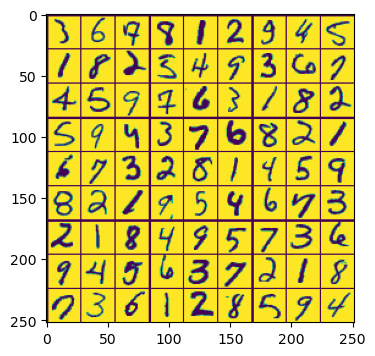

In [248]:
plt.figure(figsize=(4,4))
plt.imshow(test_boards[0])

In [249]:
predictions = []
for i in tqdm(range(200)):
    grid = get_grid(i)
    predictions.append(int(valid_sudoku(grid)))

100%|██████████| 200/200 [00:09<00:00, 21.53it/s]


# Submission

<Axes: >

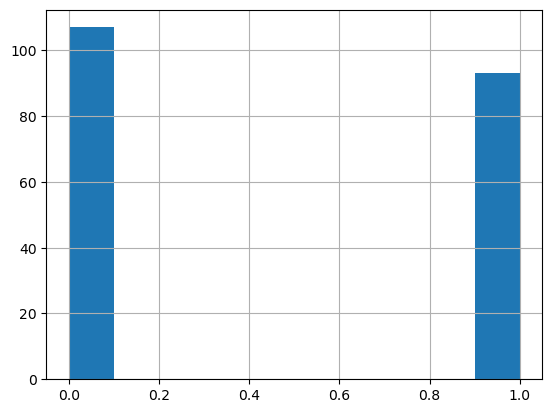

In [250]:
sub = pd.DataFrame({
    "subtaskID": 1,
    "datapointID": range(200),
    "answer": predictions,
})

sub.to_csv(f"{root_path}/sudoku_sub.csv", index=False)
sub["answer"].hist()

In [251]:
sub.head()

,subtaskID,datapointID,answer
0,1,0,0
1,1,1,0
2,1,2,0
3,1,3,1
4,1,4,1
